# 01 — Exploratory Data Analysis

**Project:** Business Data Analysis and Revenue Prediction Platform  
**Dataset:** `data/raw/business_revenue_dataset.csv`  
**Purpose:** Understand the dataset structure, distributions, correlations, and feature relationships before modelling.

---

## Notebook Structure

1. Setup & Data Loading
2. Dataset Overview
3. Data Quality Checks
4. Descriptive Statistics
5. Feature Distribution Analysis
6. Revenue Distribution Analysis
7. Correlation Analysis
8. Scatter Plot Analysis
9. EDA Summary

## 1. Setup & Data Loading

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────────────────────
# Using a clean, professional style suitable for portfolio and reports.
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_palette('Blues_d')

# ── Output directories ────────────────────────────────────────────────────────
DIST_DIR   = '../results/visualizations/distributions'
CORR_DIR   = '../results/visualizations/correlation'
SCATTER_DIR = '../results/visualizations/scatter_plots'

for d in [DIST_DIR, CORR_DIR, SCATTER_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Load dataset ──────────────────────────────────────────────────────────────
DATA_PATH = '../data/raw/business_revenue_dataset.csv'
df = pd.read_csv(DATA_PATH)

print('Dataset loaded successfully.')
print(f'Path : {DATA_PATH}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

Dataset loaded successfully.
Path : ../data/raw/business_revenue_dataset.csv
Shape: 5,000 rows x 8 columns


## 2. Dataset Overview

In [2]:
print('=' * 50)
print('  DATASET OVERVIEW')
print('=' * 50)
print(f'  Rows     : {df.shape[0]:,}')
print(f'  Columns  : {df.shape[1]}')
print()
print('  Input Features (7):')
input_features = [
    'marketing_spend', 'advertising_spend', 'website_traffic',
    'number_of_customers', 'product_price',
    'discount_percentage', 'previous_revenue'
]
for i, col in enumerate(input_features, 1):
    print(f'    {i}. {col}')
print()
print('  Target Variable (1):')
print('    8. revenue')
print()
print('  Column names:')
print(f'    {list(df.columns)}')

  DATASET OVERVIEW
  Rows     : 5,000
  Columns  : 8

  Input Features (7):
    1. marketing_spend
    2. advertising_spend
    3. website_traffic
    4. number_of_customers
    5. product_price
    6. discount_percentage
    7. previous_revenue

  Target Variable (1):
    8. revenue

  Column names:
    ['marketing_spend', 'advertising_spend', 'website_traffic', 'number_of_customers', 'product_price', 'discount_percentage', 'previous_revenue', 'revenue']


In [3]:
# Preview the first 5 rows
print('First 5 rows:')
df.head()

First 5 rows:


,marketing_spend,advertising_spend,website_traffic,number_of_customers,product_price,discount_percentage,previous_revenue,revenue
0,38923.85,12538.68,119536.56,1705.59,372.98,47.71,186620.23,134820.99
1,22505.04,17928.10,122471.95,1010.50,497.95,49.52,222087.86,97624.05
2,43071.30,24068.06,53645.23,1244.22,30.08,41.66,492655.70,224871.46
3,35171.03,10783.61,18941.92,2534.16,130.01,22.19,60413.16,124550.52
4,5614.69,2478.17,51033.47,1786.26,302.89,27.37,73592.54,69174.09


In [4]:
# Preview the last 5 rows
print('Last 5 rows:')
df.tail()

Last 5 rows:


,marketing_spend,advertising_spend,website_traffic,number_of_customers,product_price,discount_percentage,previous_revenue,revenue
4995,11953.66,11602.30,141154.11,3161.57,14.78,36.81,327999.12,216582.43
4996,9251.09,8382.49,95840.81,2110.27,204.26,27.39,431415.65,231277.76
4997,24086.31,8541.53,28257.11,2697.97,281.88,30.03,239872.88,187823.41
4998,18306.20,11442.74,58197.69,2336.32,88.69,48.64,151737.66,107500.07
4999,31146.27,16106.96,142153.90,1220.42,323.53,7.65,155015.42,134138.45


## 3. Data Quality Checks

Even though the dataset is synthetic (and therefore generated cleanly), we still run
a full data quality check. This simulates the real Data Science workflow where you
**always** inspect data before using it — you never assume it is clean.

In [5]:
print('=' * 50)
print('  DATA TYPES')
print('=' * 50)
print(df.dtypes)
print()
# All columns should be float64 — numeric, no strings, no objects.
# If any column showed 'object' dtype here, it would indicate a 
# parsing error or mixed data types that need cleaning.

  DATA TYPES
marketing_spend        float64
advertising_spend      float64
website_traffic        float64
number_of_customers    float64
product_price          float64
discount_percentage    float64
previous_revenue       float64
revenue                float64
dtype: object



In [6]:
print('=' * 50)
print('  MISSING VALUES')
print('=' * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
})
print(missing_report)
print()
total_missing = missing.sum()
if total_missing == 0:
    print('  Result: No missing values found. Dataset is complete.')
else:
    print(f'  Result: {total_missing} missing values found. Cleaning required.')

  MISSING VALUES
                     Missing Count  Missing (%)
marketing_spend                  0          0.0
advertising_spend                0          0.0
website_traffic                  0          0.0
number_of_customers              0          0.0
product_price                    0          0.0
discount_percentage              0          0.0
previous_revenue                 0          0.0
revenue                          0          0.0

  Result: No missing values found. Dataset is complete.


In [7]:
print('=' * 50)
print('  DUPLICATE RECORDS')
print('=' * 50)
n_duplicates = df.duplicated().sum()
print(f'  Duplicate rows: {n_duplicates}')
if n_duplicates == 0:
    print('  Result: No duplicate rows found.')
else:
    print(f'  Result: {n_duplicates} duplicate rows found. Review required.')

  DUPLICATE RECORDS
  Duplicate rows: 0
  Result: No duplicate rows found.


In [8]:
print('=' * 50)
print('  FEATURE RANGE VALIDATION')
print('=' * 50)

# Define the expected valid ranges for each column.
# Any value outside these ranges would indicate a data generation error
# or a data quality problem in a real dataset.
ranges = {
    'marketing_spend':     (1_000,    50_000),
    'advertising_spend':   (500,      30_000),
    'website_traffic':     (5_000,   200_000),
    'number_of_customers': (100,       5_000),
    'product_price':       (10,          500),
    'discount_percentage': (0,            50),
    'previous_revenue':    (20_000,  500_000),
    'revenue':             (5_000,       None),  # Only a lower bound
}

all_ok = True
for col, (low, high) in ranges.items():
    below = (df[col] < low).sum() if low is not None else 0
    above = (df[col] > high).sum() if high is not None else 0
    status = 'OK' if (below + above) == 0 else 'ISSUE'
    if status == 'ISSUE':
        all_ok = False
    range_str = f'[{low:>7,} – {high:>7,}]' if high else f'[>= {low:,}]'
    print(f'  {col:<25} {range_str}  {status}')

print()
print('  Result: All values within expected ranges.' if all_ok else '  Result: Issues detected. Review required.')

  FEATURE RANGE VALIDATION
  marketing_spend           [  1,000 –  50,000]  OK
  advertising_spend         [    500 –  30,000]  OK
  website_traffic           [  5,000 – 200,000]  OK
  number_of_customers       [    100 –   5,000]  OK
  product_price             [     10 –     500]  OK
  discount_percentage       [      0 –      50]  OK
  previous_revenue          [ 20,000 – 500,000]  OK
  revenue                   [>= 5,000]  OK

  Result: All values within expected ranges.


## 4. Descriptive Statistics

Descriptive statistics give us a numerical summary of each feature:
- **count** — number of non-null values
- **mean** — average value
- **std** — standard deviation (spread around the mean)
- **min / max** — extreme values
- **25% / 50% / 75%** — quartiles (the 50% is the median)

In [9]:
stats = df.describe().T
stats.columns = ['count', 'mean', 'std', 'min', '25%', '50% (median)', '75%', 'max']
stats = stats.round(2)
print('Descriptive Statistics:')
stats

Descriptive Statistics:


,count,mean,std,min,25%,50% (median),75%,max
marketing_spend,5000.0,25285.01,14137.83,1025.42,12976.00,25107.16,37684.40,49988.50
advertising_spend,5000.0,15280.30,6331.84,932.58,10366.66,15287.78,20174.72,29632.05
website_traffic,5000.0,89958.41,41894.07,7122.85,53433.33,90280.34,125377.29,172243.83
number_of_customers,5000.0,2012.14,870.24,222.20,1273.64,2027.27,2732.88,3802.06
product_price,5000.0,255.10,141.83,10.08,132.61,254.76,381.10,499.99
discount_percentage,5000.0,25.24,14.38,0.00,12.78,25.14,37.84,50.00
previous_revenue,5000.0,258183.06,138303.10,20068.45,135218.08,259516.74,375778.78,499893.34
revenue,5000.0,165608.96,51202.17,36068.55,126410.96,163692.04,202423.69,346836.36


In [10]:
# Revenue statistics highlighted separately — this is the target variable
print('Revenue (Target Variable) Summary:')
print(f'  Min    : ${df["revenue"].min():>12,.2f}')
print(f'  Max    : ${df["revenue"].max():>12,.2f}')
print(f'  Mean   : ${df["revenue"].mean():>12,.2f}')
print(f'  Median : ${df["revenue"].median():>12,.2f}')
print(f'  Std    : ${df["revenue"].std():>12,.2f}')
print(f'  Range  : ${df["revenue"].max() - df["revenue"].min():>12,.2f}')

Revenue (Target Variable) Summary:
  Min    : $   36,068.55
  Max    : $  346,836.36
  Mean   : $  165,608.96
  Median : $  163,692.04
  Std    : $   51,202.17
  Range  : $  310,767.81


## 5. Feature Distribution Analysis

We visualize the distribution of each input feature using:
- **Histogram** — shows how values are spread across bins
- **KDE curve** — a smooth estimate of the probability distribution
- **Box plot** — shows median, quartiles, and outliers

Understanding distributions helps identify skew, outliers, and whether
features are roughly normal — all relevant for model interpretation.

In [11]:
# ── Helper: format axis labels as currency or plain numbers ──────────────────
def format_currency_axis(ax, axis='x'):
    """Format tick labels as $K or $M for readability."""
    def formatter(x, _):
        if abs(x) >= 1_000_000:
            return f'${x/1_000_000:.1f}M'
        elif abs(x) >= 1_000:
            return f'${x/1_000:.0f}K'
        return f'${x:.0f}'
    target_axis = ax.xaxis if axis == 'x' else ax.yaxis
    target_axis.set_major_formatter(mticker.FuncFormatter(formatter))

def format_number_axis(ax, axis='x'):
    """Format large tick labels with K suffix."""
    def formatter(x, _):
        if abs(x) >= 1_000_000:
            return f'{x/1_000_000:.1f}M'
        elif abs(x) >= 1_000:
            return f'{x/1_000:.0f}K'
        return f'{x:.0f}'
    target_axis = ax.xaxis if axis == 'x' else ax.yaxis
    target_axis.set_major_formatter(mticker.FuncFormatter(formatter))

print('Helper functions defined.')

Helper functions defined.


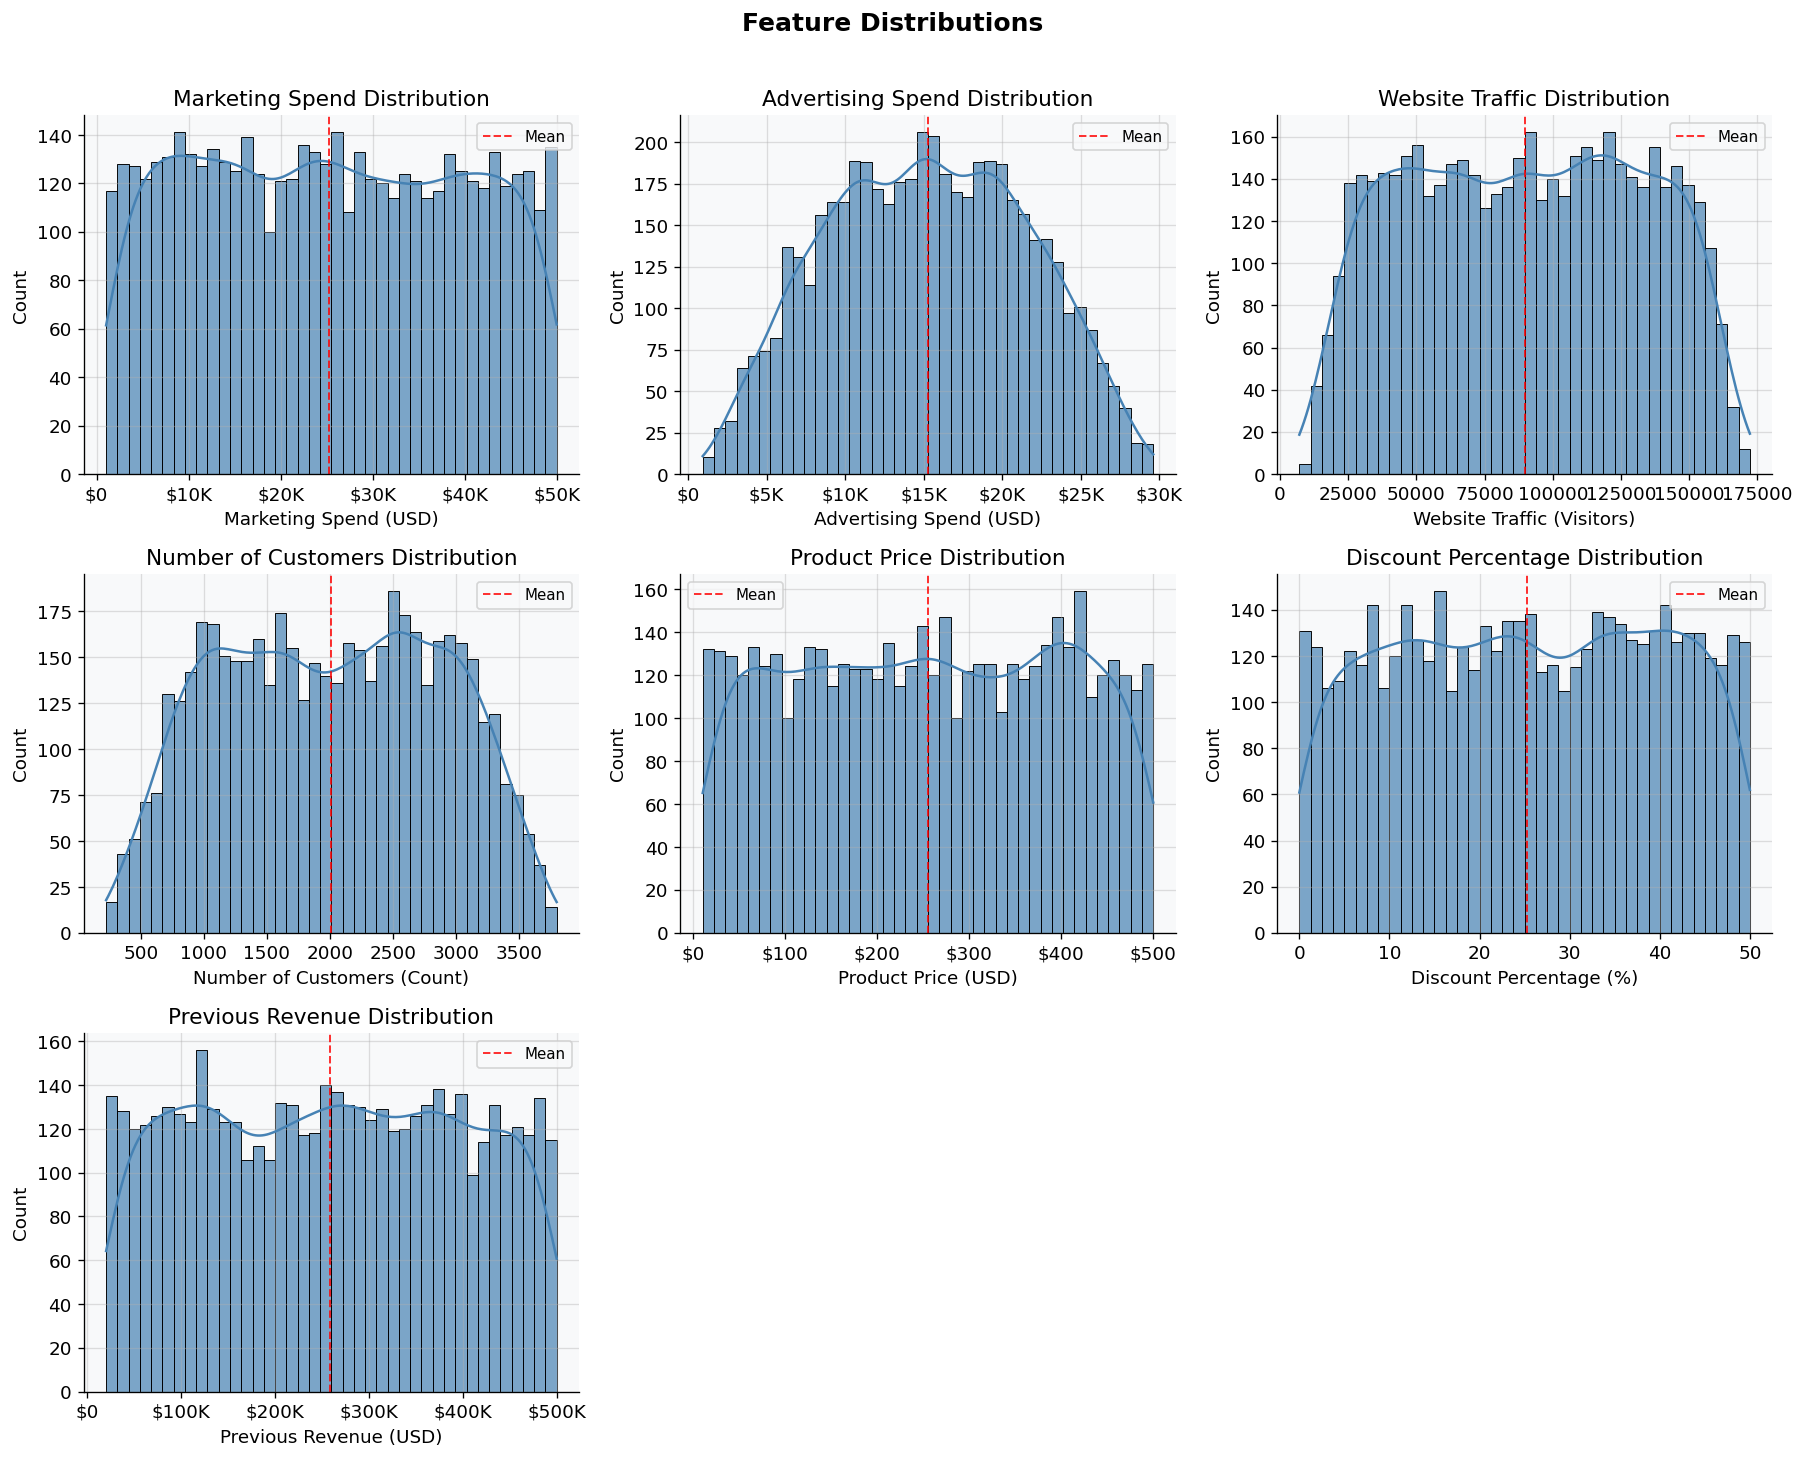

Saved: ../results/visualizations/distributions\feature_distributions.png


In [12]:
# ── Distribution plots for all 7 input features ──────────────────────────────
# Each subplot shows a histogram with a KDE overlay.
# The KDE (Kernel Density Estimate) is a smoothed version of the histogram
# that shows the overall shape of the distribution.

feature_config = [
    ('marketing_spend',     'Marketing Spend',      'USD',  True),
    ('advertising_spend',   'Advertising Spend',    'USD',  True),
    ('website_traffic',     'Website Traffic',      'Visitors', False),
    ('number_of_customers', 'Number of Customers',  'Count', False),
    ('product_price',       'Product Price',        'USD',  True),
    ('discount_percentage', 'Discount Percentage',  '%',    False),
    ('previous_revenue',    'Previous Revenue',     'USD',  True),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (col, label, unit, is_currency) in enumerate(feature_config):
    ax = axes[i]
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color='steelblue', alpha=0.7)
    ax.set_title(f'{label} Distribution')
    ax.set_xlabel(f'{label} ({unit})')
    ax.set_ylabel('Count')
    if is_currency:
        format_currency_axis(ax, 'x')
    # Add vertical mean line
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.2, alpha=0.8, label=f'Mean')
    ax.legend(fontsize=9)

# Hide the 8th and 9th unused subplots
for j in range(len(feature_config), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = os.path.join(DIST_DIR, 'feature_distributions.png')
plt.savefig(save_path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Saved: {save_path}')

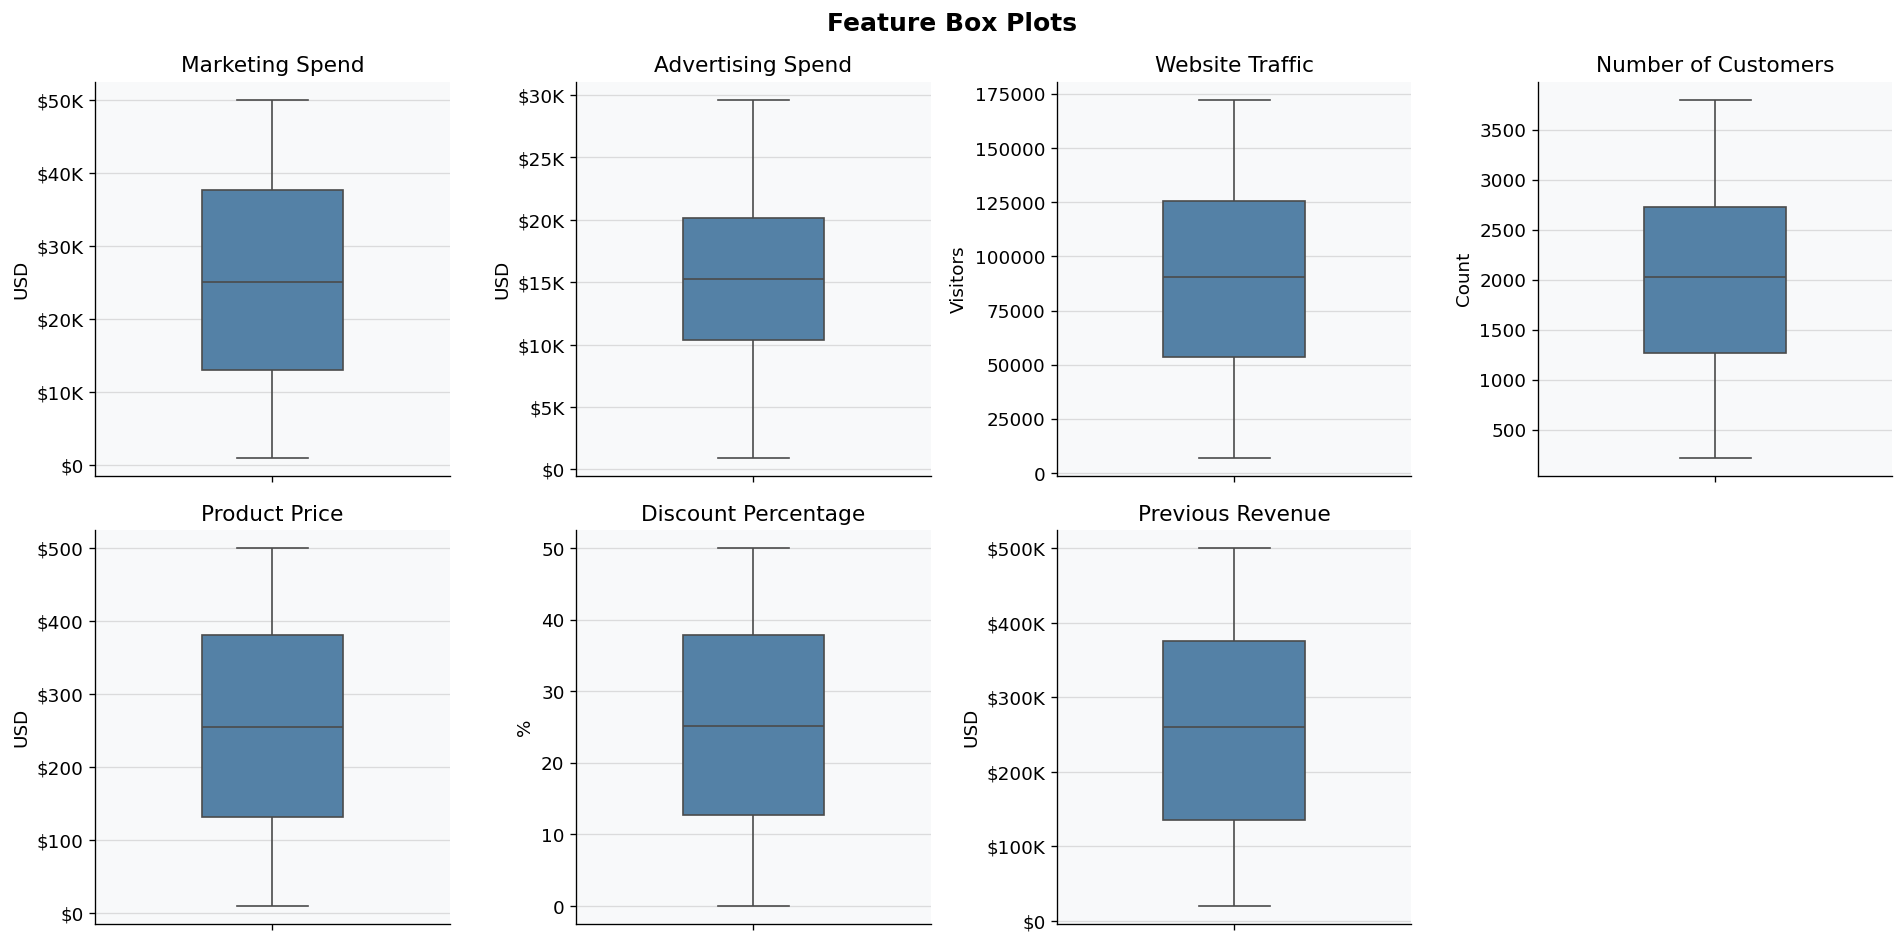

Saved: ../results/visualizations/distributions\feature_boxplots.png


In [13]:
# ── Box plots for all input features ─────────────────────────────────────────
# Box plots show: median (center line), IQR (box), whiskers (1.5x IQR),
# and individual points beyond the whiskers (outliers).
# They are especially useful for spotting skew and outliers at a glance.

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (col, label, unit, is_currency) in enumerate(feature_config):
    ax = axes[i]
    sns.boxplot(y=df[col], ax=ax, color='steelblue', width=0.4, flierprops={'markersize': 2})
    ax.set_title(f'{label}')
    ax.set_ylabel(f'{unit}')
    ax.set_xlabel('')
    if is_currency:
        format_currency_axis(ax, 'y')

axes[-1].set_visible(False)

plt.suptitle('Feature Box Plots', fontsize=15, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(DIST_DIR, 'feature_boxplots.png')
plt.savefig(save_path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Saved: {save_path}')

## 6. Revenue Distribution Analysis

Revenue is our **target variable** — the value the model will learn to predict.
Understanding its distribution is critical because:
- A heavily skewed target can affect model performance
- The range tells us what prediction errors are meaningful
- The shape tells us whether transformations (e.g., log transform) might help

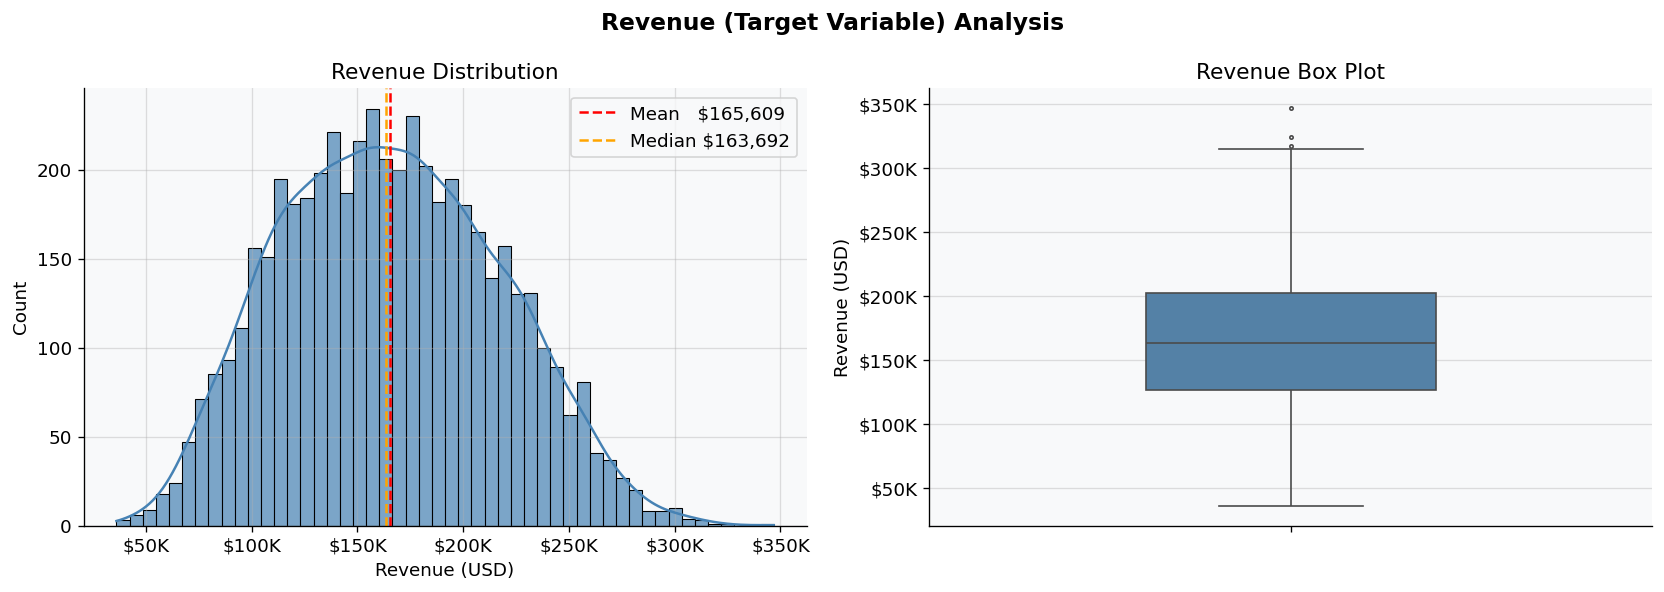

Saved: ../results/visualizations/distributions\revenue_distribution.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram + KDE
ax1 = axes[0]
sns.histplot(df['revenue'], bins=50, kde=True, ax=ax1, color='steelblue', alpha=0.7)
ax1.axvline(df['revenue'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean   ${df["revenue"].mean():,.0f}')
ax1.axvline(df['revenue'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median ${df["revenue"].median():,.0f}')
ax1.set_title('Revenue Distribution')
ax1.set_xlabel('Revenue (USD)')
ax1.set_ylabel('Count')
format_currency_axis(ax1, 'x')
ax1.legend()

# Right: box plot
ax2 = axes[1]
sns.boxplot(y=df['revenue'], ax=ax2, color='steelblue', width=0.4, flierprops={'markersize': 2})
ax2.set_title('Revenue Box Plot')
ax2.set_ylabel('Revenue (USD)')
format_currency_axis(ax2, 'y')

plt.suptitle('Revenue (Target Variable) Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(DIST_DIR, 'revenue_distribution.png')
plt.savefig(save_path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Saved: {save_path}')

## 7. Correlation Analysis

Correlation measures the **linear relationship** between two variables.

| Correlation Value | Interpretation |
|---|---|
| +1.0 | Perfect positive linear relationship |
| +0.7 to +0.9 | Strong positive |
| +0.4 to +0.7 | Moderate positive |
| +0.1 to +0.4 | Weak positive |
| ~0.0 | No linear relationship |
| Negative values | Negative relationship (as one increases, the other decreases) |

> **Important note:** Correlation measures *linear* relationships only.
> A near-zero correlation does not necessarily mean two variables are unrelated —
> they could have a non-linear relationship.

In [15]:
# ── Correlation matrix ────────────────────────────────────────────────────────
corr_matrix = df.corr()
print('Correlation Matrix:')
corr_matrix.round(3)

Correlation Matrix:


,marketing_spend,advertising_spend,website_traffic,number_of_customers,product_price,discount_percentage,previous_revenue,revenue
marketing_spend,1.000,0.463,0.071,0.022,-0.017,-0.006,0.031,0.291
advertising_spend,0.463,1.000,0.133,0.016,-0.019,0.003,0.025,0.217
website_traffic,0.071,0.133,1.000,0.237,0.000,-0.015,-0.007,0.144
number_of_customers,0.022,0.016,0.237,1.000,-0.004,-0.017,0.013,0.373
product_price,-0.017,-0.019,0.000,-0.004,1.000,-0.039,0.002,0.038
discount_percentage,-0.006,0.003,-0.015,-0.017,-0.039,1.000,0.023,-0.049
previous_revenue,0.031,0.025,-0.007,0.013,0.002,0.023,1.000,0.824
revenue,0.291,0.217,0.144,0.373,0.038,-0.049,0.824,1.000


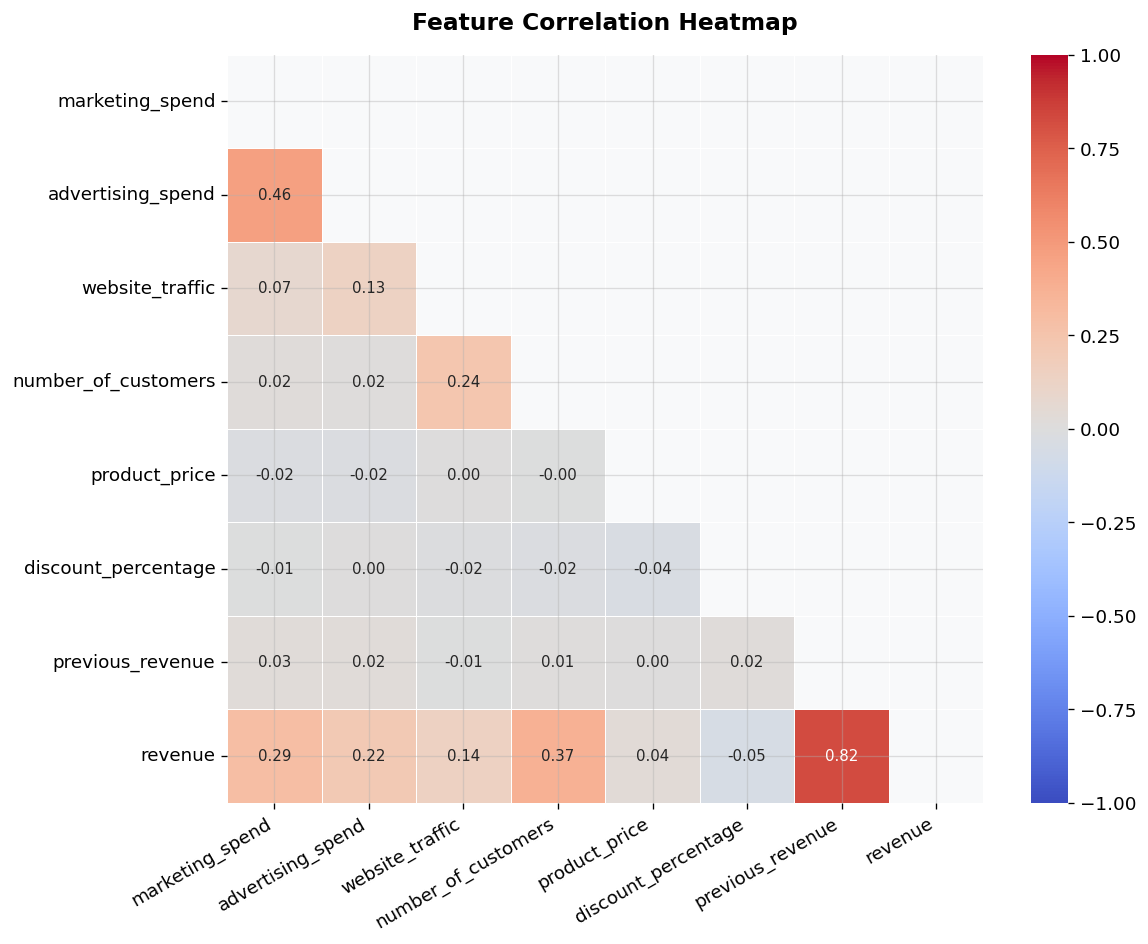

Saved: ../results/visualizations/correlation\correlation_heatmap.png


In [16]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
# The heatmap visualizes the entire correlation matrix at once.
# - Dark blue = strong positive correlation
# - Dark red  = strong negative correlation
# - White     = near-zero correlation

fig, ax = plt.subplots(figsize=(10, 8))

# Create a mask for the upper triangle — avoids showing duplicate values
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 9}
)

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save_path = os.path.join(CORR_DIR, 'correlation_heatmap.png')
plt.savefig(save_path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Saved: {save_path}')

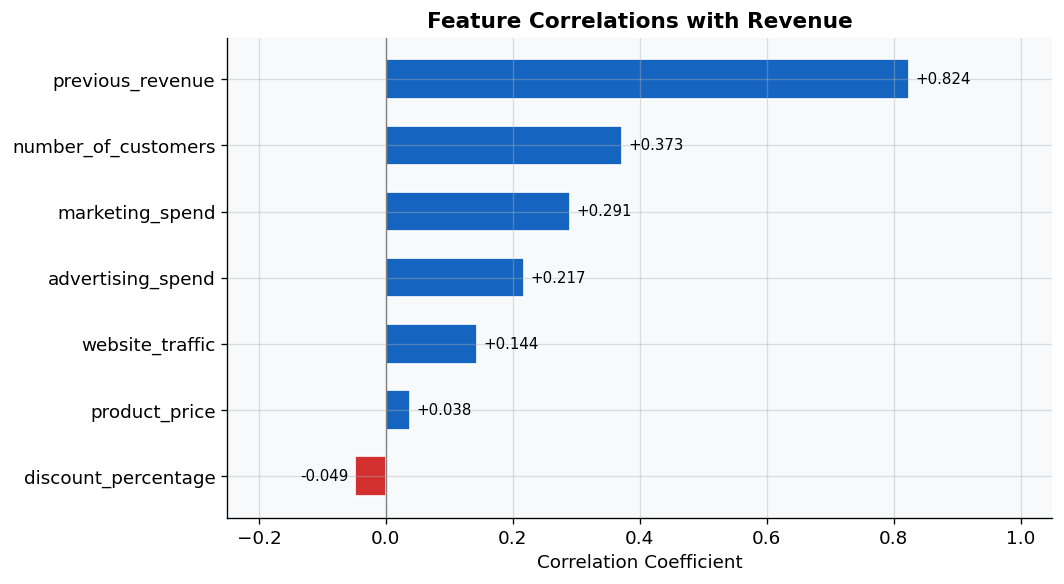

Saved: ../results/visualizations/correlation\revenue_correlations.png

Correlation with Revenue (sorted):
  previous_revenue          +0.824  (Strong Positive)
  number_of_customers       +0.373  (Moderate Positive)
  marketing_spend           +0.291  (Weak Positive)
  advertising_spend         +0.217  (Weak Positive)
  website_traffic           +0.144  (Weak Positive)
  product_price             +0.038  (Weak Positive)
  discount_percentage       -0.049  (Weak Negative)


In [17]:
# ── Correlation with Revenue (bar chart) ─────────────────────────────────────
# This isolates how strongly each input feature correlates with the target.
# Features with higher absolute correlation are more useful for prediction.

revenue_corr = corr_matrix['revenue'].drop('revenue').sort_values()

colors = ['#d32f2f' if v < 0 else '#1565c0' for v in revenue_corr.values]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(revenue_corr.index, revenue_corr.values, color=colors, edgecolor='white', height=0.6)

# Annotate each bar with its value
for bar, val in zip(bars, revenue_corr.values):
    xpos = val + 0.01 if val >= 0 else val - 0.01
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=9)

ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Correlation Coefficient')
ax.set_title('Feature Correlations with Revenue', fontsize=13, fontweight='bold')
ax.set_xlim(-0.25, 1.05)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
save_path = os.path.join(CORR_DIR, 'revenue_correlations.png')
plt.savefig(save_path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Saved: {save_path}')
print()
print('Correlation with Revenue (sorted):')
for feat, val in revenue_corr.sort_values(ascending=False).items():
    direction = 'Positive' if val > 0 else 'Negative'
    strength  = 'Strong' if abs(val) > 0.6 else 'Moderate' if abs(val) > 0.3 else 'Weak'
    print(f'  {feat:<25} {val:+.3f}  ({strength} {direction})')

## 8. Scatter Plot Analysis

Scatter plots show the **relationship between one input feature and Revenue**.
Each dot represents one business record.

What to look for:
- **Upward trend** → positive relationship with revenue
- **Downward trend** → negative relationship with revenue
- **No trend / cloud** → weak or no linear relationship
- **Spread around the trend** → noise / variance in the data

The regression line (added automatically) shows the best-fit linear trend.

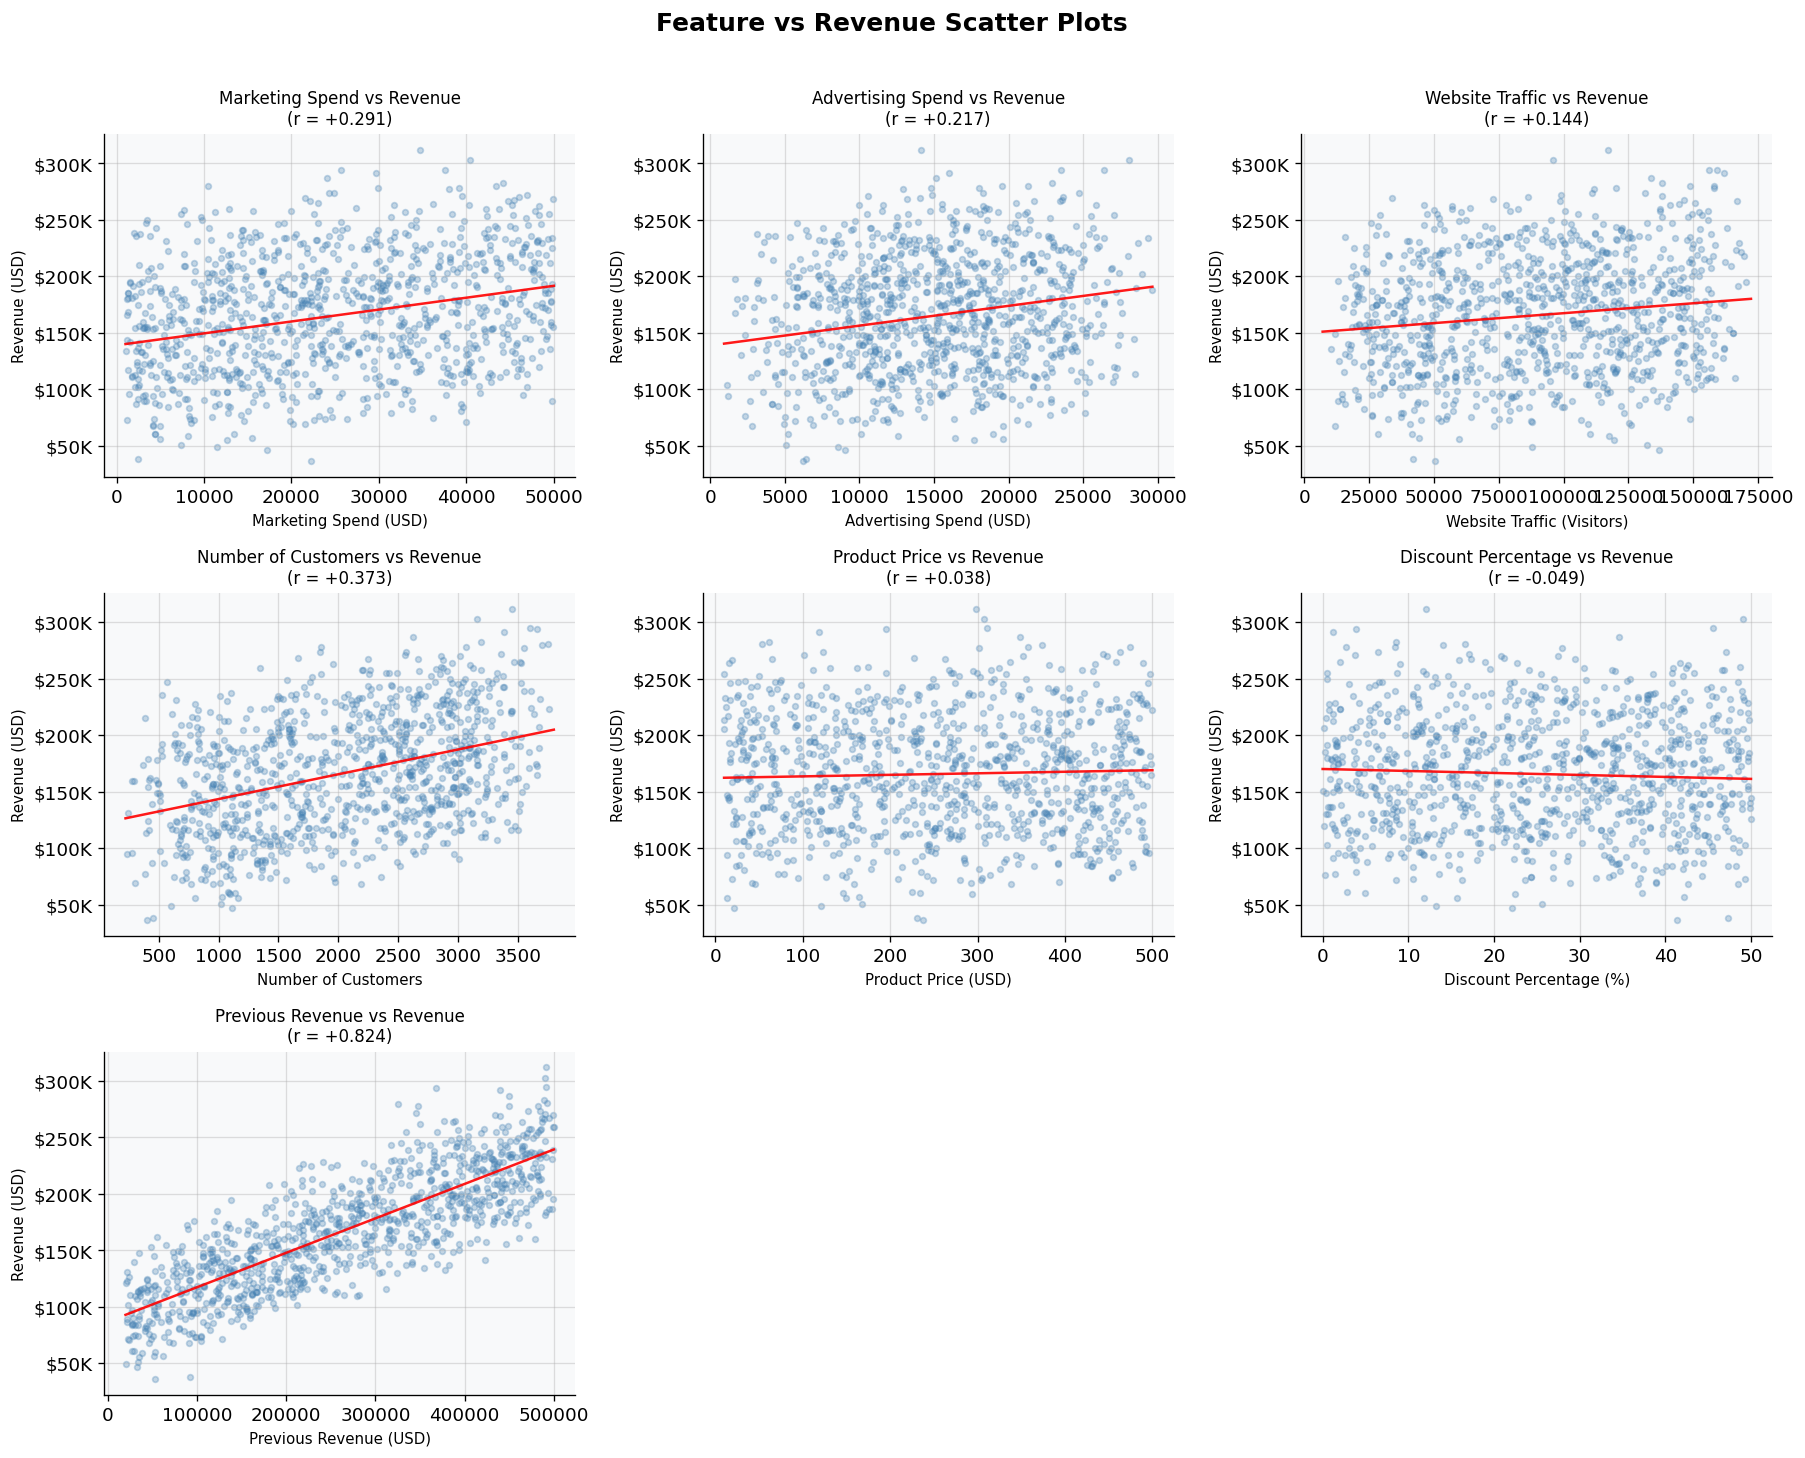

Saved: ../results/visualizations/scatter_plots\features_vs_revenue.png


In [18]:
# ── Scatter: all features vs Revenue ─────────────────────────────────────────

scatter_config = [
    ('marketing_spend',     'Marketing Spend (USD)'),
    ('advertising_spend',   'Advertising Spend (USD)'),
    ('website_traffic',     'Website Traffic (Visitors)'),
    ('number_of_customers', 'Number of Customers'),
    ('product_price',       'Product Price (USD)'),
    ('discount_percentage', 'Discount Percentage (%)'),
    ('previous_revenue',    'Previous Revenue (USD)'),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (col, xlabel) in enumerate(scatter_config):
    ax = axes[i]
    corr_val = df[col].corr(df['revenue'])

    # Plot a sample of 1000 points to keep scatter plots readable
    sample = df[[col, 'revenue']].sample(n=1000, random_state=42)
    ax.scatter(sample[col], sample['revenue'],
               alpha=0.3, s=12, color='steelblue')

    # Add linear regression trend line
    z = np.polyfit(df[col], df['revenue'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 200)
    ax.plot(x_line, p(x_line), color='red', linewidth=1.5, alpha=0.9)

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Revenue (USD)', fontsize=9)
    ax.set_title(f'{xlabel.split(" (")[0]} vs Revenue\n(r = {corr_val:+.3f})', fontsize=10)
    format_currency_axis(ax, 'y')

# Hide unused subplots
for j in range(len(scatter_config), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature vs Revenue Scatter Plots', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = os.path.join(SCATTER_DIR, 'features_vs_revenue.png')
plt.savefig(save_path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Saved: {save_path}')

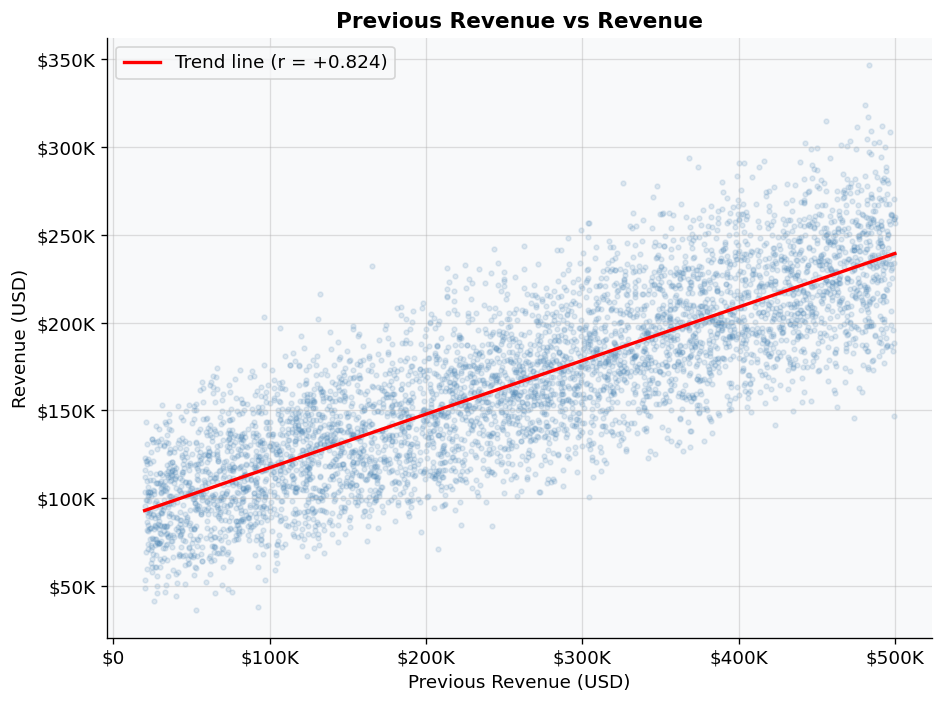

Saved: ../results/visualizations/scatter_plots\previous_revenue_vs_revenue.png


In [19]:
# ── Individual scatter: Previous Revenue vs Revenue ───────────────────────────
# This is the most important scatter plot — previous_revenue has the
# strongest correlation with revenue (r ~ 0.82).
# A standalone plot shows this relationship more clearly.

fig, ax = plt.subplots(figsize=(8, 6))
corr_val = df['previous_revenue'].corr(df['revenue'])

ax.scatter(df['previous_revenue'], df['revenue'],
           alpha=0.15, s=8, color='steelblue')

z = np.polyfit(df['previous_revenue'], df['revenue'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['previous_revenue'].min(), df['previous_revenue'].max(), 300)
ax.plot(x_line, p(x_line), color='red', linewidth=2, label=f'Trend line (r = {corr_val:+.3f})')

ax.set_xlabel('Previous Revenue (USD)', fontsize=11)
ax.set_ylabel('Revenue (USD)', fontsize=11)
ax.set_title('Previous Revenue vs Revenue', fontsize=13, fontweight='bold')
format_currency_axis(ax, 'x')
format_currency_axis(ax, 'y')
ax.legend()

plt.tight_layout()
save_path = os.path.join(SCATTER_DIR, 'previous_revenue_vs_revenue.png')
plt.savefig(save_path, bbox_inches='tight', dpi=120)
plt.show()
print(f'Saved: {save_path}')

## 9. EDA Summary

This section provides a consolidated summary of all findings.

In [20]:
print('=' * 60)
print('  EDA SUMMARY')
print('=' * 60)

print()
print('DATASET')
print(f'  Samples   : {len(df):,}')
print(f'  Features  : {len(df.columns) - 1} input features + 1 target')
print(f'  Missing   : 0 values')
print(f'  Duplicates: 0 rows')
print(f'  All data types are numeric (float64)')

print()
print('REVENUE (TARGET)')
print(f'  Range  : ${df["revenue"].min():,.0f} – ${df["revenue"].max():,.0f}')
print(f'  Mean   : ${df["revenue"].mean():,.0f}')
print(f'  Median : ${df["revenue"].median():,.0f}')
print(f'  The mean and median are close, indicating near-symmetric distribution.')

print()
print('CORRELATIONS WITH REVENUE')
revenue_corr = df.corr()['revenue'].drop('revenue').sort_values(ascending=False)
for feat, val in revenue_corr.items():
    direction = 'Positive' if val > 0 else 'Negative'
    strength  = 'Strong' if abs(val) > 0.6 else 'Moderate' if abs(val) > 0.3 else 'Weak'
    print(f'  {feat:<25} {val:+.3f}  {strength} {direction}')

print()
print('KEY OBSERVATIONS')
print('  1. previous_revenue has the strongest correlation with revenue.')
print('     This is realistic: business momentum carries forward.')
print('  2. number_of_customers and marketing_spend show moderate positive')
print('     correlations — more customers and marketing spend drive more revenue.')
print('  3. discount_percentage shows a small negative correlation,')
print('     consistent with discounts reducing revenue.')
print('  4. product_price shows near-zero correlation. This is because price')
print('     effects are diluted by varying customer counts and discount levels.')
print('  5. Features are not perfectly correlated with revenue — the noise')
print('     ensures a realistic, non-trivial prediction task for the ML model.')

print()
print('SAVED VISUALIZATIONS')
for d in [DIST_DIR, CORR_DIR, SCATTER_DIR]:
    files = [f for f in os.listdir(d) if f.endswith('.png')]
    for f in files:
        print(f'  {os.path.join(d, f)}')

print()
print('NEXT STEP: Phase 4 — Data Preparation & Feature Engineering')
print('=' * 60)

  EDA SUMMARY

DATASET
  Samples   : 5,000
  Features  : 7 input features + 1 target
  Missing   : 0 values
  Duplicates: 0 rows
  All data types are numeric (float64)

REVENUE (TARGET)
  Range  : $36,069 – $346,836
  Mean   : $165,609
  Median : $163,692
  The mean and median are close, indicating near-symmetric distribution.

CORRELATIONS WITH REVENUE
  previous_revenue          +0.824  Strong Positive
  number_of_customers       +0.373  Moderate Positive
  marketing_spend           +0.291  Weak Positive
  advertising_spend         +0.217  Weak Positive
  website_traffic           +0.144  Weak Positive
  product_price             +0.038  Weak Positive
  discount_percentage       -0.049  Weak Negative

KEY OBSERVATIONS
  1. previous_revenue has the strongest correlation with revenue.
     This is realistic: business momentum carries forward.
  2. number_of_customers and marketing_spend show moderate positive
     correlations — more customers and marketing spend drive more revenue.
  